# 네이버 블로그에서 [서울 버거 맛집] 웹크로링 데이터 약 500개 - 전처리

In [ ]:
# 네이버 블로그에서 [서울 버거 맛집] 웹크로링 데이터 약 500개 - 전처리

import pandas as pd
import re
import csv
from konlpy.tag import Okt

# csv 로 저장된 파일 열기
df = pd.read_csv('서울_버거_맛집_500.csv')

# title 컬럼에 대한 데이터 전처리 ( re, pandas )

# 가 정규식을 사용해서 데이터 전처리
# 가-1. 정규식을 사용해서 특수문자 제거 (한글, 영어, 숫자, 공백 제외)
df['title'] = df['title'].str.replace(r'[^ㄱ-ㅎㅏ-ㅣ가-힣a-zA-Z0-9 ]', '', regex=True)
# 가-2. 정규식으로 연도, 월 정보 제거 
df['title'] = df['title'].str.replace(r'\d{4}년?\s*\d{1,2}월?', '', regex=True)
df['title'] = df['title'].str.replace(r'\b\d{4}[.\s]?\d{1,2}\b\s?', '', regex=True)

# 나 표준화
# 나-1. 영문자 대문자 -> 소문자로
df['title'] = df['title'].str.lower()
# df['title'] = df['title'].str.replace('[a-zA-Z]', '', regex=True) # 옵션 : 영문자 제외

# 다 데이터 가공
# 다-1 title, content 에 데이터가 없으면 삭제
df = df.dropna(subset=['title', 'content'])

# 다-2 title 에 데이터가 중복이 경우
df = df.drop_duplicates(subset=['title'])

# 라 기타 데이터 제거
# title 컬럼에 제주, 부산 있는지 확인? 과천, 제주, 부산, 괌 인경우 행을 삭제
# df[df['title'].str.contains('제주')]
# 라-1 서울이 아닌 지역이 있으면 행 제거
df = df[~df['title'].str.contains('과천|제주|부산|괌|양평', na=False)]

# 라-2 불용어 (STOPWORD) 를 제거
stopwords = ["에서", "까지", "와", "과", "의", "로","이","가","는", "보다"] # 샘플로 10개만 
pattern = "|".join(stopwords)
df["title"] = df["title"].str.replace(pattern, "", regex=True)

# 라-3 연속된 공백제거하여 한개 공백
df["title"] = df["title"].str.replace(r'\s+', ' ', regex=True)

#df.iloc[0:50]
#print(len(df)) # 203 -> 202(중복) -> 다른지역(5개-197)

# content 컬럼에 대한 데이터 전처리 ( re, pandas, konlpy )
okt = Okt()
 
def clean_blog_content(text) :
    # 결측치(NaN) 처리
    if not isinstance(text, str):
        return ""
    # 가-1 
    # URL 제거 패턴
    url_pattern = r'https?://[a-zA-Z0-9\-.:/?=&_]+'
    # 이메일 제거 패턴
    email_pattern = r'[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}'
    # 특수문자 제거 패턴 (한글, 영문, 숫자, 공백만 남김)
    special_pattern = r'[^가-힣ㄱ-ㅎㅏ-ㅣa-zA-Z0-9\s]'

    # 순차적으로 정규식 적용
    text = re.sub(url_pattern, '', text)
    text = re.sub(email_pattern, '', text)
    text = re.sub(special_pattern, '', text)

    # 연속된 공백 하나로 줄이기 및 앞뒤 공백 제거
    text = re.sub(r'\s+', ' ', text)

    # 나-1 konlpy를 적용 - 명사 추출
    nouns = okt.nouns(text)
    # '것', '수', '등'과 같은 의미 없는 1글자 불용어 제거
    # 나-2 제거하고 싶은 불용어 리스트 정의
    stop_words = ['정말', '진짜', '오늘', '이번', '로그', '블로그', '네이버', '대박', '사건']
    nouns = [noun for noun in nouns if (noun not in stop_words) and (len(noun) > 1 or noun == '맛')]
    
    return " ".join(nouns)

#  clean_blog_content 함수를 df 적용
df['content_clean'] = df['content'].apply(clean_blog_content)

df.iloc[0:50]

# 데이터 중간 저장
output_file = '서울_버거_맛집_500_전처리_2.csv'
df.to_csv(output_file, index=False, encoding='utf-8-sig')
print('CSV_전처리_2 파일 저장완료')

# 텍스트마이닝: 네이버 블로그 - 서울 버거 맛집 500개

In [11]:
# 모듈 불러오기
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer

# 파일 열기
df = pd.read_csv('서울_버거_맛집_500_전처리-2.csv')

# 결측데이터 삭제, 공백으로 대체
df['content_clean'] = df['content_clean'].fillna('')

# DTM 생성
vectorizer = CountVectorizer(token_pattern=r"(?u)\b\w+\b")
dtm_matrix = vectorizer.fit_transform(df['content_clean'])

dtm_df = pd.DataFrame(
    dtm_matrix.toarray(),
    columns = vectorizer.get_feature_names_out()
)

# 전체 단어의 빈도를 계산
word_frequencies = dtm_df.sum(axis=0)

# 주관적인 목록 : 아래 목록에 (무슨) 버거 몇 개 나오는지 확인
target_burgers = [
    '불고기버거', '새우버거', '치킨버거', '치즈버거', '달걀버거', 
    '스테이크버거', '떡갈비버거', '밥버거', '햄버거', '바게트버거'
]

# 타겟이 되는 목록이 존재하는 데이터를 찾아봄
existing_burgers = [burger for burger in target_burgers if burger in word_frequencies.index]

# 빈도수를 추출 
burger_count_df = pd.DataFrame({
    '버거 종류': existing_burgers,
    '빈도수': [word_frequencies[burger] for burger in existing_burgers]
})

target_df = pd.DataFrame({'버거 종류': target_burgers})

# 데이터 병합
result_df = pd.merge(target_df, burger_count_df, on='버거 종류', how='left')
result_df['빈도수'] = result_df['빈도수'].fillna(0).astype(int)

# 정렬 후 결과를 다시 변수에 덮어쓰기
burger_count_df = result_df.sort_values(by='빈도수', ascending=False).reset_index(drop=True)
print(burger_count_df)


# csv 저장
burger_count_df.to_csv('burger_count.csv', index=False, encoding = 'utf-8-sig')
print('csv 파일 저장 완료: burger_count.csv')

    버거 종류   빈도수
0     햄버거  1768
1    치즈버거   704
2    새우버거   168
3    치킨버거   137
4   불고기버거    32
5  스테이크버거    28
6    달걀버거     0
7   떡갈비버거     0
8     밥버거     0
9   바게트버거     0
csv 파일 저장 완료: burger_count.csv


In [10]:
# 기존 코드에서 생성된 word_frequencies가 있다고 가정합니다.
# word_frequencies는 단어 이름이 '인덱스'이고, 등장 횟수가 '값'인 판다스 시리즈(Series)입니다.

# 1. 내가 찾고 싶은 타겟 재료 목록 정의
target_ingredients = [ 
    '번', '패티', '치즈', '양상추', '토마토',  
    '양파', '마요네즈', '케첩', '피클', '베이컨' 
]

# 2. [핵심] reindex()를 사용하여 타겟 목록만 쏙 뽑아오고, 없는 건 0으로 채우기
# - fill_value=0 : 데이터에 해당 재료가 없을 때 NaN 대신 0을 집어넣어라
ingredient_series = word_frequencies.reindex(target_ingredients, fill_value=0)

# 3. 데이터프레임(표) 형태로 예쁘게 변환
ingredient_count_df = pd.DataFrame({
    '재료 종류': ingredient_series.index,
    '빈도수': ingredient_series.values
})

# 4. 많이 언급된 순서대로 내림차순 정렬 및 순번(인덱스) 초기화
ingredient_count_df = ingredient_count_df.sort_values(by='빈도수', ascending=False).reset_index(drop=True)

# 5. 결과 출력
print(ingredient_count_df)

# csv 저장
ingredient_count_df.to_csv('ingredient_count.csv', index=False, encoding = 'utf-8-sig')
print('csv 파일 저장 완료: ingredient_count.csv')

  재료 종류   빈도수
0    패티  1510
1    치즈  1048
2   베이컨   467
3    양파   361
4    피클   266
5   토마토   227
6   양상추   123
7    케첩   117
8  마요네즈    80
9     번     0
csv 파일 저장 완료: ingredient_count.csv


# 데이터시각화

## 워드클라우드

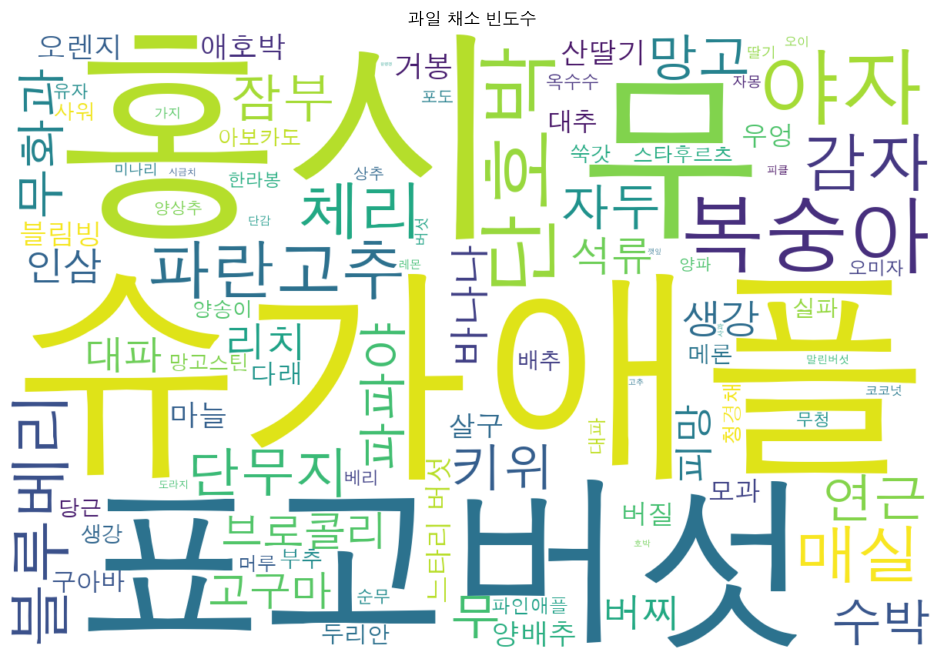

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud

plt.rcParams['font.family'] = 'AppleGothic'  # 맥의 기본 애플고딕을 그래프 폰트로 지정
plt.rcParams['axes.unicode_minus'] = False   # 마이너스 기호(-) 깨짐 방지 안전장치


df = pd.read_csv('fruit_vegetable.csv')

freq_dict = dict(zip(df['title'], df['count']))

wordcloud = WordCloud(
    font_path = '/System/Library/Fonts/Supplemental/AppleGothic.ttf',   # 한글폰트지정
    width = 1200,
    height = 800,
    background_color = 'white').generate_from_frequencies(freq_dict)

plt.figure(figsize=(12,8))   # 12인치, 8인치
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('과일 채소 빈도수')
plt.show()

In [ ]:
# 1. 시각화 및 데이터 처리에 필요한 필수 모듈 불러오기
import pandas as pd
import matplotlib.pyplot as plt                 # 데이터 시각화(그래프 틀 생성)를 위한 라이브러리
from wordcloud import WordCloud                 # 워드클라우드 이미지 생성을 위한 라이브러리

# ==========================================
# 🔥 [한글 깨짐 해결] 그래프 기계(Matplotlib) 전역 설정
# ==========================================
# plt.title()이나 축 이름 등 그래프 '바깥쪽 틀'의 글자가 네모(□)로 깨지는 것을 막아줍니다.
plt.rcParams['font.family'] = 'AppleGothic'    # 맥(Mac) 시스템의 기본 서체인 '애플고딕'을 전역 폰트로 지정
plt.rcParams['axes.unicode_minus'] = False     # 그래프에 마이너스 기호(-)가 있을 때 깨지는 현상 방지

# 2. 전처리가 완료된 빈도수 CSV 파일 불러오기
df = pd.read_csv('fruit_vegetable.csv')

# 3. 데이터프레임(표)의 내용을 워드클라우드 전용 형태인 '딕셔너리'로 변환
# - zip(df['title'], df['count']) : 과일/채소 이름과 개수를 하나씩 1:1로 짝지어줍니다.
# - dict(...) : 최종적으로 {'사과': 150, '바나나': 80} 구조의 딕셔너리를 생성합니다.
freq_dict = dict(zip(df['title'], df['count']))

# 4. 워드클라우드 이미지 생성 및 세부 옵션 설정
# - font_path : 이미지 '안쪽 알맹이 글자'들이 깨지지 않도록 맥의 실제 폰트 파일 경로를 직접 지정
# - width, height : 저장되거나 화면에 보일 워드클라우드 이미지의 가로/세로 해상도(픽셀 크기)
# - background_color : 도화지 배경색을 깔끔한 하얀색으로 설정 (기본값은 검은색)
# - generate_from_frequencies(freq_dict) : 위에서 짝지어둔 빈도수 딕셔너리를 갈아 넣어 최종 이미지 생성
wordcloud = WordCloud(
    font_path = '/System/Library/Fonts/Supplemental/AppleGothic.ttf',   
    width = 1200,
    height = 800,
    background_color = 'white'
).generate_from_frequencies(freq_dict)

# 5. 완성된 워드클라우드 이미지를 화면에 띄우기
plt.figure(figsize=(12, 8))                     # 시각화 창 크기를 가로 12인치, 세로 8인치 큼직하게 설정

# - imshow : 수치 데이터 상태인 워드클라우드를 진짜 눈에 보이는 '이미지 그림'으로 변환하여 출력
# - interpolation='bilinear' : 글자가 대폭 커지거나 작아질 때 외곽선이 깨지지 않고 부드럽게 보이도록 보정
plt.imshow(wordcloud, interpolation='bilinear')

plt.axis('off')                                 # 그래프 기본값인 가로축/세로축 눈금선과 테두리를 숨김 (포스터처럼 깔끔하게 보기 위함)
plt.title('과일 채소 빈도수', fontsize=16)       # 그래프 맨 위에 표시될 메인 제목 설정 (맨 위에서 폰트 설정을 했기에 한글이 완벽히 나옵니다)
plt.show()                                      # 모든 세팅이 반영된 최종 완성본 그림을 화면에 깨끗하게 출력

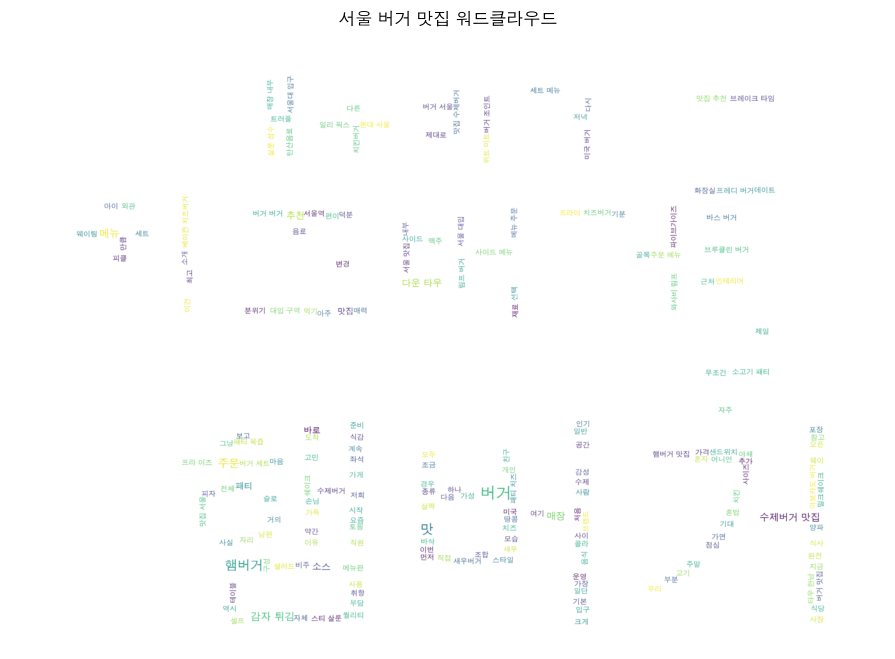

In [30]:
# 강사님 버전

import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from PIL import Image
import numpy as np

plt.rcParams['font.family'] = 'AppleGothic'  # 맥의 기본 애플고딕을 그래프 폰트로 지정
plt.rcParams['axes.unicode_minus'] = False   # 마이너스 기호(-) 깨짐 방지 안전장치


img = Image.open('/Users/garyungkim/Desktop/my_work/my_venv/image/burger.png') # 투명이미지가 원인
#imgArray = np.array(img)
# 기존 코드 대신 아래 4줄을 적용하세요
img = Image.open('/Users/garyungkim/Desktop/my_work/my_venv/image/burger.png').convert("RGBA")
# 1. 원본 이미지와 똑같은 크기의 순수 흰색(255, 255, 255, 255) 도화지 생성
white_bg = Image.new("RGBA", img.size, (255, 255, 255, 255))
# 2. 흰색 도화지 위에 투명한 버거 이미지를 위에 덮어씌우기(합성)
img_filled = Image.alpha_composite(white_bg, img).convert("RGB")
# 3. 완성된 이미지를 넘파이 배열로 변환
imgArray = np.array(img_filled)


df = pd.read_csv('서울_버거_맛집_500_전처리-2.csv')

text = " ".join(df['content_clean'].dropna())

wordcloud = WordCloud(
    font_path= '/System/Library/Fonts/Supplemental/AppleGothic.ttf', # 한글폰트지정
    width=1200,
    height=800,
    background_color = 'white',
    mask=imgArray).generate(text)

plt.figure(figsize=(12,8)) # 12인치, 8인치
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('서울 버거 맛집 워드클라우드')
plt.show()

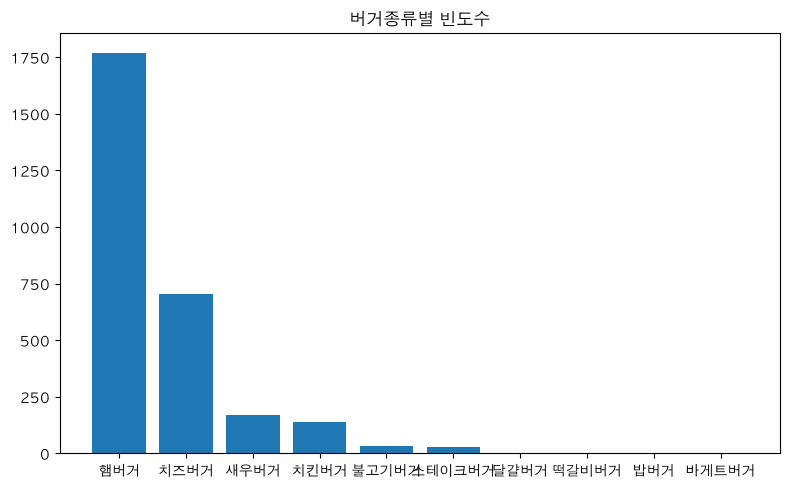

In [26]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'AppleGothic'  # 맥의 기본 애플고딕을 그래프 폰트로 지정
plt.rcParams['axes.unicode_minus'] = False   # 마이너스 기호(-) 깨짐 방지 안전장치


df = pd.read_csv('burger_count.csv')
plt.figure(figsize=(8,5))
plt.bar(df['버거 종류'], df['빈도수'])
plt.title('버거종류별 빈도수')
plt.tight_layout()
plt.show()

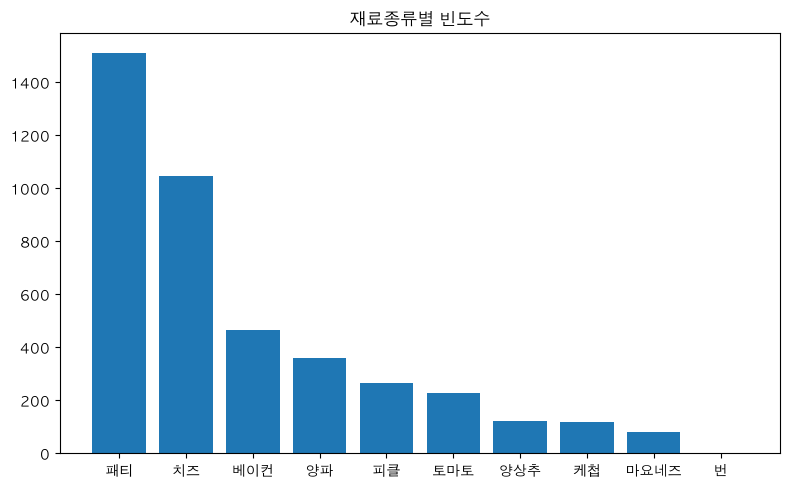

In [31]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'AppleGothic'  # 맥의 기본 애플고딕을 그래프 폰트로 지정
plt.rcParams['axes.unicode_minus'] = False   # 마이너스 기호(-) 깨짐 방지 안전장치


df = pd.read_csv('ingredient_count.csv')
plt.figure(figsize=(8,5))
plt.bar(df['재료 종류'], df['빈도수'])
plt.title('재료종류별 빈도수')
plt.tight_layout()
plt.show()

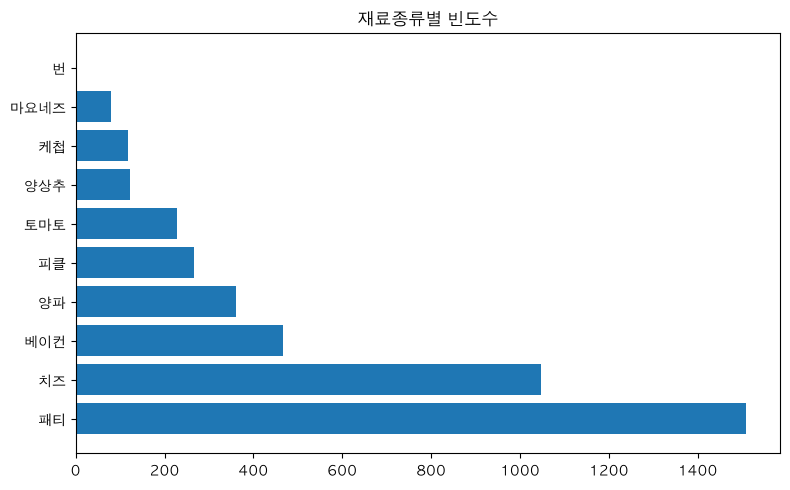

In [33]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'AppleGothic'  # 맥의 기본 애플고딕을 그래프 폰트로 지정
plt.rcParams['axes.unicode_minus'] = False   # 마이너스 기호(-) 깨짐 방지 안전장치


df = pd.read_csv('ingredient_count.csv')
plt.figure(figsize=(8,5))
plt.barh(df['재료 종류'], df['빈도수'])   # 가로 막대형으로 변경
plt.title('재료종류별 빈도수')
plt.tight_layout()
plt.show()